In [14]:
import os
import scanpy as sc
import numpy as np
from scipy.io import mmread
from scipy.sparse import csr_matrix

AF = "/data1/bfernando/DE_project/alvinfry"
OUT_DIR = f"{AF}/h5ad"
os.makedirs(OUT_DIR, exist_ok=True)
SAMPLES = ["Col-0", "pFACT", "pHORST"]

In [15]:
# look the data 
sample = SAMPLES[0]
mtx_file  = f"{AF}/counts_cr-like-em/{sample}/alevin/quants_mat.mtx"
cols_file = f"{AF}/counts_cr-like-em/{sample}/alevin/quants_mat_cols.txt"
rows_file = f"{AF}/counts_cr-like-em/{sample}/alevin/quants_mat_rows.txt"
!head -5 {mtx_file} {cols_file} {rows_file}

# genes are --> 82968 , this is 3 times the gene count

==> /data1/bfernando/DE_project/alvinfry/counts_cr-like-em/Col-0/alevin/quants_mat.mtx <==
%%MatrixMarket matrix coordinate real general
% written by sprs
192259 82968 14996054
2 4 3
2 8 1

==> /data1/bfernando/DE_project/alvinfry/counts_cr-like-em/Col-0/alevin/quants_mat_cols.txt <==
AT1G01010.Araport11.447
AT1G01040.Araport11.447
AT1G01110.Araport11.447
AT1G01160.Araport11.447
AT1G01180.Araport11.447

==> /data1/bfernando/DE_project/alvinfry/counts_cr-like-em/Col-0/alevin/quants_mat_rows.txt <==
CGCAGGTCATTCGCTA
CAACTCCCATGCTGTC
CACTCCATCCAGAGGA
AACACCGCACATATAG
CACTAACGTGCACCAC


In [16]:
all_adata = {}          # keep them in memory for the next cells

for sample in SAMPLES:

    print("=" * 60)
    print(sample)

    mtx_file  = f"{AF}/counts_cr-like-em/{sample}/alevin/quants_mat.mtx"
    cols_file = f"{AF}/counts_cr-like-em/{sample}/alevin/quants_mat_cols.txt"
    rows_file = f"{AF}/counts_cr-like-em/{sample}/alevin/quants_mat_rows.txt"

    # --- read the matrix ---------------------------------------------------
    matrix = mmread(mtx_file)
    matrix = matrix.tocsr()          # csr = fast row slicing

    # --- read the names ----------------------------------------------------
    column_names = []
    for line in open(cols_file):
        column_names.append(line.strip())

    barcode_names = []
    for line in open(rows_file):
        barcode_names.append(line.strip())

    print("  matrix shape :", matrix.shape)

    # --- find the S / U / A blocks ----------------------------------------
    n_genes = len(column_names) // 3

    start_S = 0
    end_S   = n_genes
    start_U = n_genes
    end_U   = n_genes * 2
    start_A = n_genes * 2
    end_A   = n_genes * 3

    block_S = matrix[:, start_S:end_S]
    block_U = matrix[:, start_U:end_U]
    block_A = matrix[:, start_A:end_A]

    # --- add the three layers together ------------------------------------
    counts = block_S + block_U + block_A
    counts = csr_matrix(counts)      # make sure it stays sparse

    gene_names = column_names[start_S:end_S]

    # --- build the AnnData object -----------------------------------------
    adata = sc.AnnData(counts)
    adata.obs_names = barcode_names
    adata.var_names = gene_names

    # record where it came from, so the file explains itself later
    adata.obs["sample"] = sample
    adata.uns["source"] = f"{AF}/counts_cr-like-em/{sample}"
    adata.uns["resolution"] = "cr-like-em"
    adata.uns["layers_summed"] = "S+U+A"
    adata.uns["filtered"] = False

    #uns = unstructured.

    print("  genes        :", n_genes)
    print("  barcodes     :", adata.n_obs)
    print("  total UMI    :", round(float(adata.X.sum())))

    # --- save --------------------------------------------------------------
    out_file = f"{OUT_DIR}/{sample}_cr-like-em_raw.h5ad"
    adata.write_h5ad(out_file, compression="gzip")
    print("  wrote        :", out_file)
    print("  size         :", round(os.path.getsize(out_file) / 1e6, 1), "MB")

    all_adata[sample] = adata

print("=" * 60)
print("done -", len(all_adata), "samples loaded")

Col-0


/data1/tmp/ipykernel_3726218/897229559.py:13: DeprecationWarning: The default value for `spmatrix` is changing to `False` in v1.20.
             That means the default return type will be a sparse array.
             Unless you use * instead of @, ** for matrix power, or you depend
             on 2D shapes from e.g. `A.sum(axis=0)` it may not matter to you.
             See the spmatrix to sparray migration guide for details.
             https://docs.scipy.org/doc/scipy/reference/sparse.migration_to_sparray.html
             
  matrix = mmread(mtx_file)


  matrix shape : (192259, 82968)
  genes        : 27656
  barcodes     : 192259
  total UMI    : 18123357
  wrote        : /data1/bfernando/DE_project/alvinfry/h5ad/Col-0_cr-like-em_raw.h5ad
  size         : 45.3 MB
pFACT


/data1/tmp/ipykernel_3726218/897229559.py:13: DeprecationWarning: The default value for `spmatrix` is changing to `False` in v1.20.
             That means the default return type will be a sparse array.
             Unless you use * instead of @, ** for matrix power, or you depend
             on 2D shapes from e.g. `A.sum(axis=0)` it may not matter to you.
             See the spmatrix to sparray migration guide for details.
             https://docs.scipy.org/doc/scipy/reference/sparse.migration_to_sparray.html
             
  matrix = mmread(mtx_file)


  matrix shape : (200283, 82968)
  genes        : 27656
  barcodes     : 200283
  total UMI    : 29835121
  wrote        : /data1/bfernando/DE_project/alvinfry/h5ad/pFACT_cr-like-em_raw.h5ad
  size         : 64.7 MB
pHORST


/data1/tmp/ipykernel_3726218/897229559.py:13: DeprecationWarning: The default value for `spmatrix` is changing to `False` in v1.20.
             That means the default return type will be a sparse array.
             Unless you use * instead of @, ** for matrix power, or you depend
             on 2D shapes from e.g. `A.sum(axis=0)` it may not matter to you.
             See the spmatrix to sparray migration guide for details.
             https://docs.scipy.org/doc/scipy/reference/sparse.migration_to_sparray.html
             
  matrix = mmread(mtx_file)


  matrix shape : (193477, 82968)
  genes        : 27656
  barcodes     : 193477
  total UMI    : 21889175
  wrote        : /data1/bfernando/DE_project/alvinfry/h5ad/pHORST_cr-like-em_raw.h5ad
  size         : 42.9 MB
done - 3 samples loaded


Adds per-barcode columns to `.obs`: using the calculate_qc_metric function

| column | meaning |
|---|---|
| `total_counts` | total UMIs in that barcode |
| `n_genes_by_counts` | how many distinct genes it detected |
| `pct_counts_organellar` | % of its UMIs from chloroplast/mito genes |

`ATCG*` = chloroplast genome, `ATMG*` = mitochondrial genome. Nuclei contain neither
organelle, so a clean nuclei prep should be low.

In [17]:
# more on the Scanpy calculate_qc_metric
# https://scanpy.readthedocs.io/en/stable/generated/scanpy.pp.calculate_qc_metrics.html
# returns 
# 1) total_counts - total UMIs in that barcode 
# 2) n_genes_by_counts - how many distinct genes it detected
# 3) pct_counts_organellar - % of its UMIs from chloroplast/mito genes

for sample in SAMPLES:
    adata = all_adata[sample]

    # flag the organellar genes
    adata.var["organellar"] = adata.var_names.str.startswith(("ATCG", "ATMG"))  # Adds a True/False column to .var marking the Mt and Cp genes

    sc.pp.calculate_qc_metrics(
        adata,
        qc_vars=["organellar"],
        inplace=True,
        percent_top=None,
        log1p=False,
    )

    print(f"{sample:8s} barcodes={adata.n_obs:>8,}  "
          f"median UMI={adata.obs['total_counts'].median():>7.0f}  "
          f"median genes={adata.obs['n_genes_by_counts'].median():>6.0f}  "
          f"median %organellar={adata.obs['pct_counts_organellar'].median():>5.1f}")

Col-0    barcodes= 192,259  median UMI=     64  median genes=    61  median %organellar=  3.7
pFACT    barcodes= 200,283  median UMI=    102  median genes=    97  median %organellar=  4.2
pHORST   barcodes= 193,477  median UMI=     43  median genes=    41  median %organellar=  3.8


Look at the distributions BEFORE filtering

Cell Ranger used 864 cells
Cell Ranger's lowest *called* cell had 502 UMIs while its highest *rejected* barcode had 5,153. 

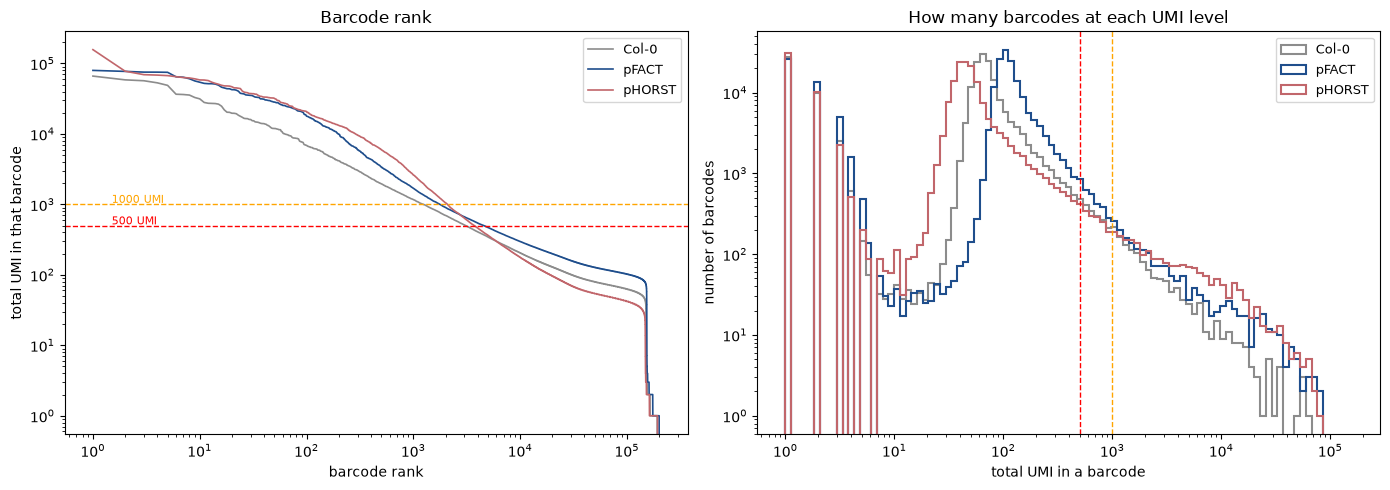

         UMI range       Col-0       pFACT      pHORST
            0 - 10      41,041      46,555      44,636
           10 - 50      11,136         550      86,864
          50 - 100     109,621      47,277      42,701
         100 - 500      27,101     101,132      15,284
       500 - 1,000       1,848       2,794       1,632
     1,000 - 5,000       1,081       1,423       1,485
            5,000+         157         350         598


In [18]:
import matplotlib.pyplot as plt
import numpy as np

COLOR = {"Col-0": "#8c8c8c", "pFACT": "#1f4e8c", "pHORST": "#c1666b"}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ---------------------------------------------------------------------------
# LEFT - barcode rank plot
# x = barcodes sorted high->low, y = that barcode's UMI count
# ---------------------------------------------------------------------------
for sample in SAMPLES:
    umi = np.sort(all_adata[sample].obs["total_counts"].values)[::-1]
    rank = np.arange(1, len(umi) + 1)
    ax1.loglog(rank, umi, lw=1.2, color=COLOR[sample], label=sample)

ax1.axhline(500, color="red", ls="--", lw=1)
ax1.axhline(1000, color="orange", ls="--", lw=1)
ax1.text(1.5, 520, "500 UMI", color="red", fontsize=8)
ax1.text(1.5, 1050, "1000 UMI", color="orange", fontsize=8)
ax1.set_xlabel("barcode rank")
ax1.set_ylabel("total UMI in that barcode")
ax1.set_title("Barcode rank")
ax1.legend(fontsize=9)

# ---------------------------------------------------------------------------
# RIGHT - how many barcodes have each UMI count
# x = UMI count (real numbers, log spaced)
# y = NUMBER OF BARCODES (not density)
# ---------------------------------------------------------------------------
# log-spaced bins so the x axis can show real UMI numbers
biggest = 0
for sample in SAMPLES:
    m = all_adata[sample].obs["total_counts"].values.max()
    if m > biggest:
        biggest = m

bins = np.logspace(0, np.log10(biggest), 100)

for sample in SAMPLES:
    umi = all_adata[sample].obs["total_counts"].values
    umi = umi[umi > 0]
    ax2.hist(umi, bins=bins, histtype="step", lw=1.5,
             color=COLOR[sample], label=sample)

ax2.set_xscale("log")
ax2.set_yscale("log")          # counts span 1 to ~50,000, so log makes the tail visible

ax2.axvline(500, color="red", ls="--", lw=1)
ax2.axvline(1000, color="orange", ls="--", lw=1)
ax2.set_xlabel("total UMI in a barcode")
ax2.set_ylabel("number of barcodes")
ax2.set_title("How many barcodes at each UMI level")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

# --- the same thing as a table ---------------------------------------------
print(f"{'UMI range':>18}", end="")
for sample in SAMPLES:
    print(f"{sample:>12}", end="")
print()

edges = [0, 10, 50, 100, 500, 1000, 5000, 10**9]
for i in range(len(edges) - 1):
    low, high = edges[i], edges[i + 1]
    label = f"{low:,} - {high:,}" if high < 10**9 else f"{low:,}+"
    print(f"{label:>18}", end="")
    for sample in SAMPLES:
        umi = all_adata[sample].obs["total_counts"].values
        n = ((umi > low) & (umi <= high)).sum()
        print(f"{n:>12,}", end="")
    print()


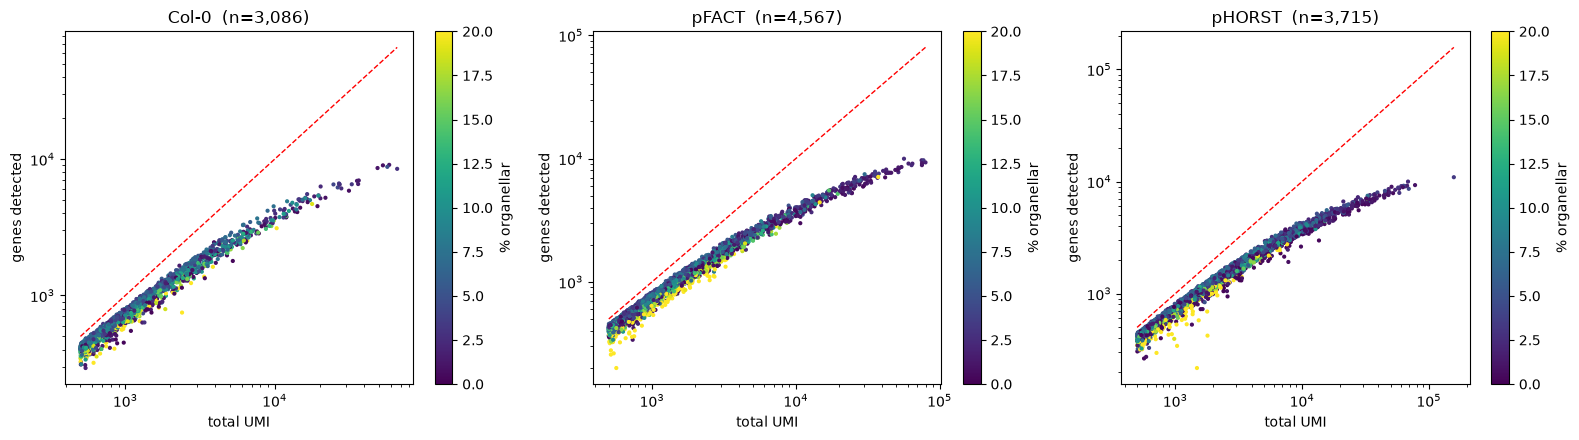

sample        n>500  median %org   90th pct   99th pct     >10%
Col-0         3,086          6.9       12.5       20.6      644
pFACT         4,567          7.1       14.8       24.5    1,263
pHORST        3,715          6.0       13.2       25.5      777


In [19]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, sample in zip(axes, SAMPLES):
    adata = all_adata[sample]
    umi   = adata.obs["total_counts"].values
    genes = adata.obs["n_genes_by_counts"].values
    org   = adata.obs["pct_counts_organellar"].values

    keep = umi > 500                      # candidate cells only
    sc_ = ax.scatter(umi[keep], genes[keep], c=org[keep], s=4,
                     cmap="viridis", vmin=0, vmax=20)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.plot([500, umi.max()], [500, umi.max()], "r--", lw=1)   # 1 UMI per gene
    ax.set_xlabel("total UMI"); ax.set_ylabel("genes detected")
    ax.set_title(f"{sample}  (n={keep.sum():,})")
    plt.colorbar(sc_, ax=ax, label="% organellar")

plt.tight_layout(); plt.show()

# organellar distribution among candidate cells
print(f"{'sample':10s} {'n>500':>8} {'median %org':>12} {'90th pct':>10} {'99th pct':>10} {'>10%':>8}")
for sample in SAMPLES:
    adata = all_adata[sample]
    keep = adata.obs["total_counts"].values > 500
    org = adata.obs["pct_counts_organellar"].values[keep]
    print(f"{sample:10s} {keep.sum():>8,} {np.median(org):>12.1f} "
          f"{np.percentile(org,90):>10.1f} {np.percentile(org,99):>10.1f} "
          f"{(org>10).sum():>8,}")


In [21]:
import numpy as np

print(f"{'sample':10s} {'n>500':>8} {'min genes':>10} {'max':>9} {'median':>8} {'<200?':>8}")
for sample in SAMPLES:
    adata = all_adata[sample]
    keep = adata.obs["total_counts"].values > 500
    genes = adata.obs["n_genes_by_counts"].values[keep]
    print(f"{sample:10s} {keep.sum():>8,} {genes.min():>10.0f} "
          f"{np.max(genes):>8.0f}{np.median(genes):>8.0f} "
          f"{(genes < 200).sum():>8,}")


sample        n>500  min genes       max   median    <200?
Col-0         3,086        293     9089     635        0
pFACT         4,567        200     9967     620        0
pHORST        3,715        217    10921     808        0


In [22]:
# extracting out barcodes with < 500 genes as empty droplets
# setting the threshold values based on the above
# thresholds
# adding no filder for genes since in genes in every cell is 200, the scanpy default
# is to filder cells with genes less than 0
MIN_COUNTS = 500
MAX_ORGANELLAR = 10       # scanpy's default based on google AI search 

filtered = {}

for sample in SAMPLES:
    adata = all_adata[sample]

    umi   = adata.obs["total_counts"].values
    genes = adata.obs["n_genes_by_counts"].values
    org   = adata.obs["pct_counts_organellar"].values

    # --- see what each filter removes, one at a time -----------------------
    pass_umi   = umi > MIN_COUNTS
    pass_org   = org < MAX_ORGANELLAR
    # called cell if it passes the threshold
    is_cell    = pass_umi & pass_org

    print("=" * 62)
    print(f"{sample}   ({adata.n_obs:,} barcodes)")
    print(f"  pass UMI  > {MIN_COUNTS:<6} : {pass_umi.sum():>8,}")
    print(f"  pass org  < {MAX_ORGANELLAR}%     : {pass_org.sum():>8,}")
    print(f"  pass ALL THREE      : {is_cell.sum():>8,}  <- cells")

    # --- write the flag onto the full object -------------------------------
    adata.obs["is_cell"] = is_cell

    # --- and make a filtered copy ------------------------------------------
    # deleting nothing just marking cells as True
    cells = adata[is_cell].copy()

    cells.uns["filtered"] = True
    cells.uns["filter_min_counts"] = MIN_COUNTS
    cells.uns["filter_max_pct_organellar"] = MAX_ORGANELLAR

    print(f"  median UMI  : {cells.obs['total_counts'].median():>8.0f}")
    print(f"  median genes: {cells.obs['n_genes_by_counts'].median():>8.0f}")

    cells.write_h5ad(f"{OUT_DIR}/{sample}_cr-like-em_filtered.h5ad", compression="gzip")
    filtered[sample] = cells

print("\nwrote *_cr-like-em_filtered.h5ad")



Col-0   (192,259 barcodes)
  pass UMI  > 500    :    3,086
  pass org  < 10%     :  181,567
  pass ALL THREE      :    2,442  <- cells
  median UMI  :      843
  median genes:      636
pFACT   (200,283 barcodes)
  pass UMI  > 500    :    4,567
  pass org  < 10%     :  191,183
  pass ALL THREE      :    3,304  <- cells
  median UMI  :      796
  median genes:      619
pHORST   (193,477 barcodes)
  pass UMI  > 500    :    3,715
  pass org  < 10%     :  174,767
  pass ALL THREE      :    2,937  <- cells
  median UMI  :     1261
  median genes:      892

wrote *_cr-like-em_filtered.h5ad
